### 42028 : Deep Learning and CNN
### Assignment 1

| Name | Swapnil Ajit Chhatre |
| :--- | :--- |
| Student ID | 25675238 |
| Tutorial | 04 (Wednesday 12.00 - 15.00) |
| Tutor | Mr. Deep Patel |

#### Aim
- To develop SVM and Neural Network classifiers for handwritten mathematical symbol classification.
- To use Histogram Of Oriented Gradients (HoG), Local Binary Pattern (LBP), Raw images/pixels, and any other feature for classification

### Contents
1. Section 1 : Loading Dataset
2. Section 2 : Exploratory Data Analysis
3. Section 3 : Dataset Preparation
4. Section 4 : Image Processing

### File Outcome
*A set of processed grayscale images that are used for feature extraction and model training*

### Library imports

In [5]:
!pip install opencv-python --verbose 2

Using pip 25.3 from /opt/conda/lib/python3.12/site-packages/pip (python 3.12)
ERROR: Could not find a version that satisfies the requirement 2 (from versions: none)
ERROR: No matching distribution found for 2


In [6]:
#Required libraries and global variables
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import tensorflow as tf

from skimage import feature
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

dataset_path = "./student_25675238/"

2026-03-25 06:33:30.369300: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Section 1 : Loading the Dataset

In [7]:
!ls

Assignment_1_ANN.ipynb		  features	 student_25675238
Assignment_1_Preprocessing.ipynb  metadata.json  student_25675238.zip
Assignment_1_SVM.ipynb		  original_data


In [ ]:
# !unzip student_25675238.zip # Dataset is already unzipped and extracted

In [8]:
!ls $dataset_path

 1   8	 C   N	 R  '['   b   p   sqrt	 y


*It can be observed that the dataset contains the following 10 classes of handwritten characters:*
- 1
- 8
- C
- N
- R
- '[' : Opening bracket
- b
- p
- sqrt : Square root symbol
- y

In [9]:
!find ./student_25675238/ -maxdepth 2 -type f -iname "*.jpg" -printf '%h\n' | sort | uniq -c | awk '{printf "%-25s : %s images\n", $2, $1}'

./student_25675238/1      : 500 images
./student_25675238/8      : 500 images
./student_25675238/C      : 500 images
./student_25675238/N      : 500 images
./student_25675238/R      : 500 images
./student_25675238/[      : 500 images
./student_25675238/b      : 500 images
./student_25675238/p      : 500 images
./student_25675238/sqrt   : 500 images
./student_25675238/y      : 500 images


*Each of the 10 classes consists of 500 image files in corresponding directory*

In [10]:
!find ./student_25675238/ -maxdepth 2 -type f -iname "*.jpg" | wc -l | awk '{printf "Total number of images : %s", $1}'

Total number of images : 5000

### Section 2 : Exploratory Data Analysis

*In this section, we explore the characteristics of this dataset by focussing on one category for ease of explanantion. We will use OpenCV library to access and examine the images*

*As shown in the previous sections, the dataset contains of 10 classes of hadnwritten characters which can be letters, numbers, special characters or mathematical symbols.* 

*Each class consists of 500 images, bringing the total number of images to 5000.*

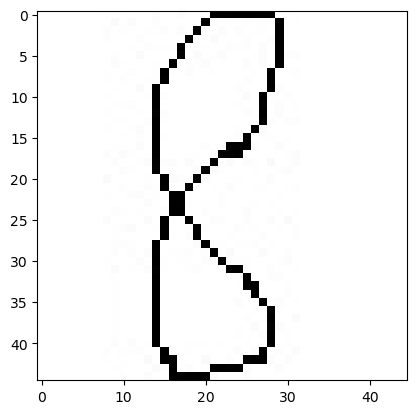

In [11]:
#Analysing sample image from class "8"

folder_path = dataset_path + "/8"
image_path = os.listdir(folder_path)
img = cv2.imread(folder_path + "/" + image_path[0])
plt.imshow(img)
plt.show()

In [12]:
#Displaying image dimensions and data types

print("Image dimensions :", img.shape)
print("Image data type :", img.dtype)
print("Image width :", img.shape[0])
print("Image length :", img.shape[1])

Image dimensions : (45, 45, 3)
Image data type : uint8
Image width : 45
Image length : 45


*The aforementioned information shows that the image is a 45X45 image with 3 channels (RGB)*

### Section 3 : Dataset Preparation

*In this section, we create a single array of all images which currently exist in separate folders.*
*This array is then divided into training, validation, and testing sets for the model*
*A similar operation is performed for creating an array of class labels, which is also divided into training, validation, and testing sets.*

In [13]:
#Listing all class folders from the main dataset folder and adding folder name to a list

class_folders = []
for f in os.listdir(dataset_path):
    if os.path.isdir(os.path.join(dataset_path, f)) and f != ".ipynb_checkpoints":
        class_folders.append(f)

print(class_folders)

['1', '8', 'C', 'N', 'R', '[', 'b', 'p', 'sqrt', 'y']


In [14]:
#Accessing each folder from class_folders list and adding the images to a list and 
#equal number of class labels to another list
#This will be the image set and label set which will be used for modelling

images = []
labels = []

for folder_name in class_folders:
    folder_path = dataset_path + "/" + folder_name
    for image in os.listdir(folder_path):
        #Verifying image file to avoid any hidden files or ipynb checkpoints
        if ".jpg" in image:
            img_array = cv2.imread(folder_path + "/" + image) #Reading images using opencv and adding to list
            images.append(img_array)
            labels.append(folder_name)
    print("All images added for label : " + folder_name)        

All images added for label : 1
All images added for label : 8
All images added for label : C
All images added for label : N
All images added for label : R
All images added for label : [
All images added for label : b
All images added for label : p
All images added for label : sqrt
All images added for label : y


In [15]:
print("Total number of images :", len(images))

Total number of images : 5000


In [16]:
print("Total number of labels :", len(labels))

Total number of labels : 5000


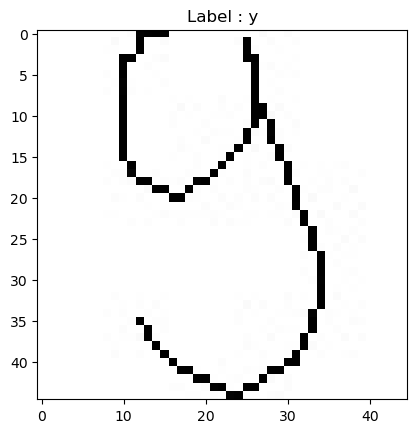

In [17]:
#Reading a random image and it's label from the lists
idx = random.randint(0, 4999)
label = labels[idx]
plt.title("Label : " + label)
plt.imshow(images[idx])
plt.show()

In [18]:
#Writing the raw images and labels to .npy files for reuse
images_np_array = np.array(images)
labels_np_array = np.array(labels)

np.save('./original_data/images.npy', images_np_array)
np.save('./original_data/labels.npy', labels_np_array)

### Section 4 : Image Processing 

*Converting images to grayscale. The original dataset contains images with 3 channels i.e. RGB. However, features like HOG and LBP are computed on single-channel i.e. grayscale images to reduce computational cost and loss of shape information.* 

In [19]:
#Loading images and labels from saved files
images = np.load('./original_data/images.npy')
labels = np.load('./original_data/labels.npy')

In [20]:
#Converting images to grayscale
gray_images = []
for img in images:
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_images.append(gray_img)
print("Total number of Gray Images :", len(gray_images))

Total number of Gray Images : 5000


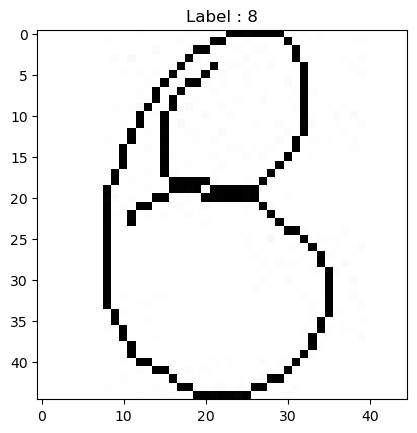

In [21]:
#Reading a random gray image and it's label from the lists
idx = random.randint(0, 4999)
label = labels[idx]
plt.title("Label : " + label)
plt.imshow(gray_images[idx], cmap='gray') # Using color map as gray for converted grayscale images
plt.show()

In [22]:
#Printing image shape
print("Image dimensions :", gray_images[idx].shape)
print("Image data type :", gray_images[idx].dtype)
print("Image width :", gray_images[idx].shape[0])
print("Image length :", gray_images[idx].shape[1])

Image dimensions : (45, 45)
Image data type : uint8
Image width : 45
Image length : 45


*It can be observed here that the image does not have the 3 channels which were present in the original dataset.*

**Note : Although, the image still appears as black and white with the colormap=gray attribute value, the change in the number of channels is the proof that this is a grayscale image**

In [23]:
#Saving grayscale images to a .npy file for reuse
gray_images_np_array = np.array(gray_images)
np.save('./features/grayscale_images.npy', gray_images_np_array)

*Furthermore, the image is normalized such that all values lie between a fixed range of 0-1 for simplicity of computation*

In [24]:
#Normalisation
processed_images = []
for img in gray_images:
    prc_img = img/255.0
    processed_images.append(prc_img)
print("Total number of Processed Images :", len(gray_images))

Total number of Processed Images : 5000


In [25]:
#Printing a random processed image and it's label from the lists
idx = random.randint(0, 4999)
label = labels[idx]
print("Label : " + label)
print(processed_images[idx])

Label : 8
[[1.         1.         1.         ... 1.         1.         1.        ]
 [1.         0.99215686 1.         ... 1.         1.         1.        ]
 [1.         1.         0.99607843 ... 1.         1.         1.        ]
 ...
 [1.         1.         1.         ... 1.         1.         1.        ]
 [1.         1.         1.         ... 1.         1.         1.        ]
 [1.         1.         1.         ... 1.         1.         1.        ]]


*Here it is observed that the image pixels are converted to a fixed range of 0-1*

In [26]:
#Saving processed images to a .npy file for reuse
prc_images_np_array = np.array(processed_images)
np.save('./features/processed_images.npy', prc_images_np_array)

### Section 5 : Feature Extraction (HoG, LBP, GLCM, and Gabor)

*Feature extraction is an important in any computer vision task as it transforms raw pixel data into identifiable information such as edges, texture, shapes, etc. which is required for object detection, segmentation, recognition, and classification. Feature extraction also helps in reducing the dimensionality of the image which enables the algorithms to focus on important information instead of irrelevant parts of the image.*

*In this section, the following four feature extraction techniques are used to convert the processed images from previous section into useful features*

1. Histogram of Gradients (HoG) : Represents the distribution of local gradients in form of histograms of orientation.
2. Local Binary Patterns (LBP) : LBP captures local texture information by defining a binary pattern for each pixel by comparing the intensity values of its neighbours and using a threshold to converting these intensity values to 0 or 1
3. Gray Level Co-occurrence Matrix (GLCM) : GLCM captures the spatial relationship between pixels based on their values.
4. Gabor Filters : Gabor filters are a set of linear filters tuned to different frequencies and orientations which capture the local frequency and orientation information in an image.

In [4]:
#Loading processed images from previous section
processed_images = np.load('processed_images.npy')
labels = np.load('labels.npy')

#### 1. Histogram of Gradients

In [13]:
#Extracting features using HoG
hog_features = []
for img in processed_images:
    hog = feature.hog(
        image=img,
        orientations=9,
        pixels_per_cell=(15,15),
        cells_per_block=(2,2)
    )
    hog_features.append(hog)
print("Total number of HoG Image Features :", len(hog_features))

Total number of HoG Image Features : 5000


In [14]:
print(len(hog_features[0]))

144


In [16]:
#Saving HoG features to a .npy file for reuse
hog_np_array = np.array(hog_features)
np.save('hog_features.npy', hog_features)

##### HoG Feature Vector Length Calculation

*It can be observed that the length of the HoG feature is 144. The calculation can be explained as follows-*

**Number of Cells**

= (Image length / Vertical no. of pixels per cell) x (Image width / Horizontal no. of pixels per cell)

= (45/15) x (45/15)

= 3 x 3 cells in total

**Number of Blocks**

= (Number of horizontal cells - Number of horizontal cells per block + 1) x (Number of vertical cells - Number of vertical cells per block + 1)

= (3 - 2 + 1) x (3 - 2 + 1)

= 2 x 2 = 4 blocks

**Features per block**

= Orientation x Total Cells

= 9 bins x 4 blocks = 36 features per block

**Total features**

= Number of blocks x Features per block

= 4 x 36 = *144*

#### 2. Local Binary Pattern

In [10]:
#Function to calculate spatial histograms for cells

def calculate_histogram(lbp):
    cell_size = 15
    histograms = []
    for i in range(0, 45, cell_size):
        for j in range(0, 45, cell_size):
            cell = lbp[i : i + cell_size, j : j + cell_size]

            hist, _ = np.histogram(
                cell.ravel(),
                bins = np.arange(0, 11),
                range = (0, 10)
            )

            hist = np.float32(hist)
            hist /= (hist.sum() + 1e-7)
            histograms.append(hist)
    lbp_feature_vector = np.concatenate(histograms)
    return lbp_feature_vector

In [11]:
#Extracting features using HoG
lbp_features = []
P_value = 8 #Number of neighbours to be considered
R_value = 1 #Radius of circle = P/8

for img in processed_images:
    lbp = feature.local_binary_pattern(
        image=img,
        P=P_value,
        R=R_value,
        method="uniform",
    )

    lbp_feature_vector = calculate_histogram(lbp)
    lbp_features.append(lbp_feature_vector)

print("Total number of LBP Image Features :", len(lbp_features))

Total number of LBP Image Features : 5000


In [12]:
print(len(lbp_features[0]))

90


In [17]:
#Saving LBP features to a .npy file for reuse
lbp_np_array = np.array(lbp_features)
np.save('lbp_features.npy', lbp_features)

### Section 6 : Splitting Dataset

In [3]:
#Importing raw grayscale images, hog features, and lbp features

raw_pixel = np.load('processed_images.npy')
hog_features = np.load('hog_features.npy')
lbp_features = np.load('lbp_features.npy')

In [4]:
#Flattening raw_pixel values
raw_pixel = raw_pixel.reshape(-1,2025)

In [5]:
print("Raw pixel feature length :" , raw_pixel.shape)
print("HOG feature length :" , hog_features.shape)
print("LBP feature length :" , lbp_features.shape)

Raw pixel feature length : (5000, 2025)
HOG feature length : (5000, 144)
LBP feature length : (5000, 90)


In [6]:
#Importing labels
labels = np.load('labels.npy')

In [7]:
#Splitting raw image, HoG features and LBP features
#Using 70% data for training and 30% for testing

raw_pixel_x_train, raw_pixel_x_test, raw_pixel_y_train, raw_pixel_y_test = train_test_split(
    raw_pixel, labels,
    test_size=0.3, 
    train_size=0.7, 
    random_state=44
)
hog_x_train, hog_x_test, hog_y_train, hog_y_test = train_test_split(
    hog_features, labels,
    test_size=0.3, 
    train_size=0.7, 
    random_state=44
)
lbp_x_train, lbp_x_test, lbp_y_train, lbp_y_test = train_test_split(
    lbp_features, labels,
    test_size=0.3, 
    train_size=0.7, 
    random_state=44
)

In [8]:
#Displaying train and test set sizes

print("Raw pixel training set images :", len(raw_pixel_x_train))
print("Raw pixel training set labels :", len(raw_pixel_x_test))
print("Raw pixel training set images :", len(raw_pixel_y_train))
print("Raw pixel training set labels :", len(raw_pixel_y_test))

print("HOG training set images :", len(hog_x_train))
print("HOG training set labels :", len(hog_x_test))
print("HOG training set images :", len(hog_y_train))
print("HOG training set labels :", len(hog_y_test))

print("LBP training set images :", len(lbp_x_train))
print("LBP training set labels :", len(lbp_x_test))
print("LBP training set images :", len(lbp_y_train))
print("LBP training set labels :", len(lbp_y_test))

Raw pixel training set images : 3500
Raw pixel training set labels : 1500
Raw pixel training set images : 3500
Raw pixel training set labels : 1500
HOG training set images : 3500
HOG training set labels : 1500
HOG training set images : 3500
HOG training set labels : 1500
LBP training set images : 3500
LBP training set labels : 1500
LBP training set images : 3500
LBP training set labels : 1500


### Section 7 : Building SVM Model

*In this section we build a Support Vector Machine (SVM) model to train on raw pixel, HoG, and LBP features.*

In [20]:
#Define 3 SVM models with same parameters
svm_model_raw_pixel = svm.SVC(
    kernel='poly',
    C=50,
    random_state=44
)
svm_model_hog = svm.SVC(
    kernel='poly',
    C=50,
    random_state=44
)
svm_model_lbp = svm.SVC(
    kernel='poly',
    C=50,
    random_state=44
)

In [21]:
#Fitting the SVM model for raw images
svm_model_raw_pixel.fit(raw_pixel_x_train, raw_pixel_y_train)
print("SVM model trained on raw pixel data")

SVM model trained on raw pixel data


In [22]:
#Fitting the SVM model for hog features
svm_model_hog.fit(hog_x_train, hog_y_train)
print("SVM model trained on HoG features")

SVM model trained on HoG features


In [23]:
#Fitting the SVM model for lbp features
svm_model_lbp.fit(lbp_x_train, lbp_y_train)
print("SVM model trained on LBP features")

SVM model trained on LBP features


In [24]:
#Predicting results on testing data
raw_pixel_y_pred = svm_model_raw_pixel.predict(raw_pixel_x_test)
hog_y_pred = svm_model_hog.predict(hog_x_test)
lbp_y_pred = svm_model_lbp.predict(lbp_x_test)
print("Predictions complete by SVM")

Predictions complete by SVM


In [26]:
#Evaluating predicted results against testing labels
print("Accuracy of SVM on raw images :{:.2f}".format(metrics.accuracy_score(raw_pixel_y_test, raw_pixel_y_pred)))
print("Accuracy of SVM on HoG features :{:.2f}".format(metrics.accuracy_score(hog_y_test, hog_y_pred)))
print("Accuracy of SVM on LBP features :{:.2f}".format(metrics.accuracy_score(lbp_y_test, lbp_y_pred)))

Accuracy of SVM on raw images :0.91
Accuracy of SVM on HoG features :0.94
Accuracy of SVM on LBP features :0.85


In [27]:
raw_pixel_cm = metrics.confusion_matrix(raw_pixel_y_test, raw_pixel_y_pred)
print(raw_pixel_cm)

[[129   0   0   1   0   0   1   0   0   6]
 [  0 143   0   0   1   0   4   1   0   2]
 [  0   0 154   0   0   0   1   0   1   0]
 [  0   0   0 145   3   0   2   3   2   4]
 [  2   1   3   7 118   3   0  10  13   1]
 [  2   0   0   0   0 139   0   0   0   0]
 [  5   8   0   0   0   1 128   1   0   0]
 [  1   0   0   3   5   0   0 128   1   2]
 [  1   0   0   0   9   1   0   1 141   0]
 [  8   2   0   4   4   0   3   2   0 139]]


In [28]:
hog_cm = metrics.confusion_matrix(hog_y_test, hog_y_pred)
print(hog_cm)

[[131   0   0   0   0   4   0   0   0   2]
 [  0 147   0   0   0   0   1   1   0   2]
 [  0   0 154   0   0   1   1   0   0   0]
 [  1   0   0 153   4   0   1   0   0   0]
 [  0   3   2   4 137   0   0   6   6   0]
 [  3   0   1   0   3 132   0   0   0   2]
 [  2   5   1   0   0   0 134   0   0   1]
 [  2   0   0   0   5   0   0 132   0   1]
 [  0   0   0   0   3   1   0   0 148   1]
 [  3   7   0   0   2   1   6   2   0 141]]


In [29]:
lbp_cm = metrics.confusion_matrix(lbp_y_test, lbp_y_pred)
print(lbp_cm)

[[115   0   0   4   1   8   2   4   0   3]
 [  1 132   0   2   4   0   4   0   0   8]
 [  0   0 145   2   3   4   1   0   1   0]
 [  0   0   1 143   5   0   3   3   1   3]
 [  5   9   4   3 118   1   3   5   9   1]
 [  7   0   2   0   3 129   0   0   0   0]
 [  4   7   0   3   1   1 124   0   0   3]
 [  2   1   0   6   2   0   0 122   1   6]
 [  2   0   0   0   6   4   0   0 141   0]
 [  3  28   0   2   5   0   5   7   0 112]]


### Section 8 : Building ANN Model

*In this section we build a Artificial Neural Network (ANN) model to train on raw pixel, HoG, and LBP features.*

In [9]:
#ANN cannot use class labels in string format, hence the labels need to be encoded using integers
#The class labels are = ['1', '8', 'C', 'N', 'R', '[', 'b', 'p', 'sqrt', 'y']
le = LabelEncoder()

raw_pixel_y_train_encoded = le.fit_transform(raw_pixel_y_train)
raw_pixel_y_test_encoded = le.fit_transform(raw_pixel_y_test)

hog_y_train_encoded = le.fit_transform(hog_y_train)
hog_y_test_encoded = le.fit_transform(hog_y_test)

lbp_y_train_encoded = le.fit_transform(lbp_y_train)
lbp_y_test_encoded = le.fit_transform(lbp_y_test)

In [10]:
#Defining 3 ANN models as per the feature vector lengths of raw images, HoG feattures, and LBP features
ann_model_raw_pixels = Sequential([
    Input(shape=(raw_pixel.shape[1],)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
ann_model_hog = Sequential([
    Input(shape=(hog_features.shape[1],)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
ann_model_lbp = Sequential([
    Input(shape=(lbp_features.shape[1],)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [11]:
#Compiling all ANN models
ann_model_raw_pixels.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
ann_model_hog.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
ann_model_lbp.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [12]:
#Fitting the models on training data
ann_model_raw_pixels.fit(raw_pixel_x_train, raw_pixel_y_train_encoded, epochs=100)
ann_model_hog.fit(hog_x_train, hog_y_train_encoded, epochs=100)
ann_model_lbp.fit(lbp_x_train, lbp_y_train_encoded, epochs=100)

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0971 - loss: 2.4542
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0991 - loss: 2.3027
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1037 - loss: 2.3026
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1037 - loss: 2.3026
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1037 - loss: 2.3026
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1037 - loss: 2.3025
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0986 - loss: 2.3025
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1037 - loss: 2.3025
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1037 - loss: 2.3025
Epoch 10/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1000 - loss: 2.3025
Epoch 11/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1037 - loss: 2.3025
Epoch 12/100
110/110 ━━━━━━━━━━━━━━━━━━━━

In [13]:
raw_pixel_test_loss, raw_pixel_test_acc = ann_model_raw_pixels.evaluate(raw_pixel_x_test, raw_pixel_y_test_encoded)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0913 - loss: 2.3043


In [14]:
hog_test_loss, hog_test_acc = ann_model_hog.evaluate(hog_x_test, hog_y_test_encoded)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9360 - loss: 0.2149


In [15]:
lbp_test_loss, lbp_test_acc = ann_model_lbp.evaluate(lbp_x_test, lbp_y_test_encoded)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8280 - loss: 0.4871
